#  Computation of BOP Features

- input: atoms objects
- output here: all the descriptors comming from BOP (averages, atomic site based, etc)

#  Calculation of features from available libraries

- input curated BS

# TODO
- [X] Calculate site specific averages
- [ ] Distributions of descriptors / characterization of descriptors

In [17]:
import os
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures
import pandas as pd
import re

## options:

In [2]:
dataset = 'Cr-Co-W'# 'Fe-Mo'
atomsobjectloc = os.path.join(dataset, 'Atomsobjects')
components = dataset.replace('-','')
models = ['canonical','projections', 'projections_os']
cutoff = 'table'
atoms = 'initial'
moments = 16
retry = False

In [145]:
# only loop over the models
atomspickle =  os.path.join(atomsobjectloc, f'{components}-POSCAR-{atoms}-rescaled-AtomsObjects.pkl')
AtomsObjects = pd.read_pickle(atomspickle).dropna(how='any')
BS = pd.read_pickle(os.path.join(f'{dataset}','FullyCuratedParsedBriefSummary.pkl'))

In [4]:
results = {}
resultspickle = {}
for model in models:
    modelsfile = os.path.join('models', f'{components}_{model}.bx')
    print('atoms: ', atoms, 'model: ', model, '  cutoff: ', cutoff, ' moments:', moments)
    resultspickle[model] = os.path.join(dataset, 'Descriptors', f'parallel_{components}_{atoms}_{model}_{cutoff}_WUBIND_{moments}.pkl')
    if retry:
        BOPC = BopfoxFeatures(
                AtomsObjects['atoms'],modelsfile, modelname=model,
                cutoffby=cutoff, 
                binary = '/home/storage/fortimtb/CuadernoTrabajo/oldrepobopfox/src/bopfox_mpi',
                moments = moments
                )
        BOPC.calculate_bop_forall(ForceKeepSpecies=True,
                input_pickle = resultspickle[model]
                )
        results[model] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) #
    results[model] = pd.read_pickle(resultspickle[model]) #

atoms:  initial model:  canonical   cutoff:  table  moments: 16
atoms:  initial model:  projections   cutoff:  table  moments: 16
atoms:  initial model:  projections_os   cutoff:  table  moments: 16


# Failed BOP Calculations 

In [5]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dt

##  remove bad data

In [6]:
removenans = [result.dropna(inplace=True) for model, result in results.items()]

In [7]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dt

In [8]:
for (model, resultpckl), result in zip(resultspickle.items(), results.values()):
    result.to_pickle(resultpckl)

# Arrangement and averaging BOP Features 

- expand arrays of atomwise quantities to quantities averages
- calculate shape factors, $b_1 / b_2$ averages (over CP and structure)
- remove features with constant values (null variance)

In [9]:
from Tools.DatasetTools import GeneralFeaturizer as gf
from sklearn.feature_selection import VarianceThreshold
from tqdm.auto import tqdm

In [10]:
descriptorlocation = os.path.join(dataset, 'Descriptors' )
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [13]:
resultscnav = {}
specialcolumns =['U_bind','U_bond_atom', 'U_bond_atom_list'] 
remake = False
for model, result in tqdm(results.items()):
    averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[model]))
    if os.path.exists(averaged_bop_file) and not remake:
        resultscnav[model] = pd.read_pickle(averaged_bop_file)
    else:
        columnstoexpand = result.columns.drop(specialcolumns)
        df = gf.array_expansions(result, columnstoexpand)
        ThisCoordination = CNList[result.index]
        df = gf.featurize_dataframe(df, ThisCoordination)
        shape_factors = gf.get_shape_factors(df)
        df = pd.concat([result[specialcolumns[:-1]], df, shape_factors],  axis=1)
        selector = VarianceThreshold()
        selector.fit(df)
        resultscnav[model] = df.loc[:, selector.get_support()]
        resultscnav[model].to_pickle(averaged_bop_file)

  0%|          | 0/3 [00:00<?, ?it/s]

In [14]:
resultscnav['projections_os']

,U_bind,U_bond_atom,moments_1_0,moments_1_CN12,moments_1_CN13,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Co_pv6W_sv6.C14-BBA.FM,-120.002266,-110.387407,48.106100,38.787267,0.000000,0.000000,0.000000,9.318833,-418.475500,-344.764833,...,0.000000,0.000000,0.000000,1.210548,0.931245,0.875535,0.000000,0.000000,0.000000,1.039340
Co_pv6W_sv6.C14-BBA.NM,-120.002266,-110.387407,48.106100,38.787267,0.000000,0.000000,0.000000,9.318833,-418.475500,-344.764833,...,0.000000,0.000000,0.000000,1.210548,0.931245,0.875535,0.000000,0.000000,0.000000,1.039340
Cr_pv6W_sv2.D0_19-A3B.FM,-78.184461,-83.497746,15.702325,15.702325,0.000000,0.000000,0.000000,0.000000,-97.387850,-97.387850,...,0.000000,0.000000,0.000000,0.000000,1.047835,1.047835,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,-78.184461,-83.497746,15.702325,15.702325,0.000000,0.000000,0.000000,0.000000,-97.387850,-97.387850,...,0.000000,0.000000,0.000000,0.000000,1.047835,1.047835,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,-327.881431,-319.802263,25.801240,12.419027,0.000000,11.887720,1.494493,0.000000,-199.532307,-100.562993,...,0.000000,2.242107,0.598321,0.000000,0.949554,0.835211,0.000000,1.041792,0.841225,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,-311.423319,-316.000015,20.164293,7.600207,0.000000,11.023553,1.540533,0.000000,-143.288413,-57.440020,...,0.000000,1.888829,0.466215,0.000000,1.031192,0.881681,0.000000,1.159421,0.918321,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,-311.423319,-316.000015,20.164293,7.600207,0.000000,11.023553,1.540533,0.000000,-143.288413,-57.440020,...,0.000000,1.888829,0.466215,0.000000,1.031192,0.881681,0.000000,1.159421,0.918321,0.000000
Co_pv13W_sv16.chi-ABAB.NM,-344.693837,-324.720823,48.496128,14.412372,27.472552,0.000000,0.000000,6.611203,-429.008310,-131.748414,...,1.800631,0.000000,0.000000,0.720221,0.921635,1.274397,0.562604,0.000000,0.000000,1.033557
Co_pv13W_sv16.chi-ABAB.FM,-344.693837,-324.720823,48.496128,14.412372,27.472552,0.000000,0.000000,6.611203,-429.008310,-131.748414,...,1.800631,0.000000,0.000000,0.720221,0.921635,1.274397,0.562604,0.000000,0.000000,1.033557


# Characterization of BOP features 

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,8))
plt.rc('font', size=22)

In [55]:
def comparefeatures(featurename, featuresymbol, ax = None, suffix = '_0'):
    plotfeature = f'{featurename}{suffix}'
    symbol = fr'$\langle {featuresymbol} \rangle $'
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    ensamble = []
    for thisresultcnav in resultscnav.values():
        ensamble.append(thisresultcnav[plotfeature] )
    ensamble = pd.concat(ensamble, axis=0)
    thisrange = [ensamble.min(), ensamble.max()]
    for model, result in resultscnav.items():
        ax.hist(result[plotfeature], density=True, bins=100, alpha=0.81, edgecolor='k', label=model, range=thisrange)
    ax.set_xlabel(symbol)
    ax.legend()
    ax.set_ylabel('Counts')

In [100]:
def compare_many_orders(featurename, featuresymbol, norders = 3):
    fig, axes = plt.subplots(1, norders, figsize=(7*norders, 5), sharey=True)
    for i, ax in enumerate(axes):
        tfeaturename = featurename+f'_{i+1}'
        tfeaturesymbol = featuresymbol+f'_{i+1}'
        comparefeatures(tfeaturename, tfeaturesymbol, ax=ax)
        ax.legend([]).remove()
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5,1.1))
    [ax.set_ylabel('') for ax in axes[1:]]
    fig.tight_layout()
    

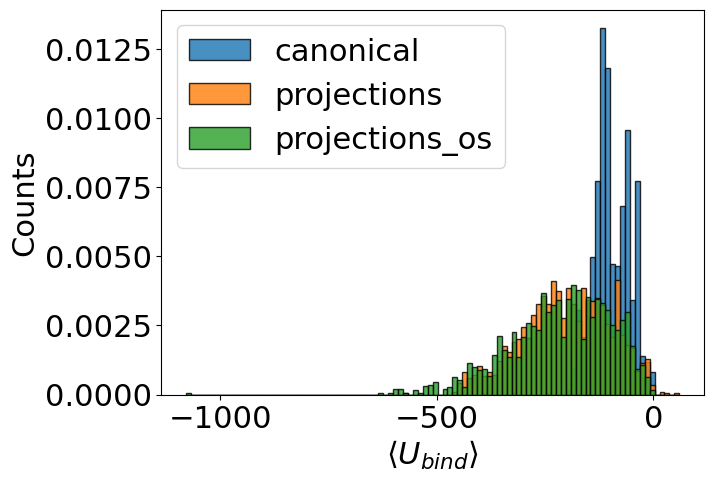

In [102]:
comparefeatures('U_bind', 'U_{bind}', suffix='')

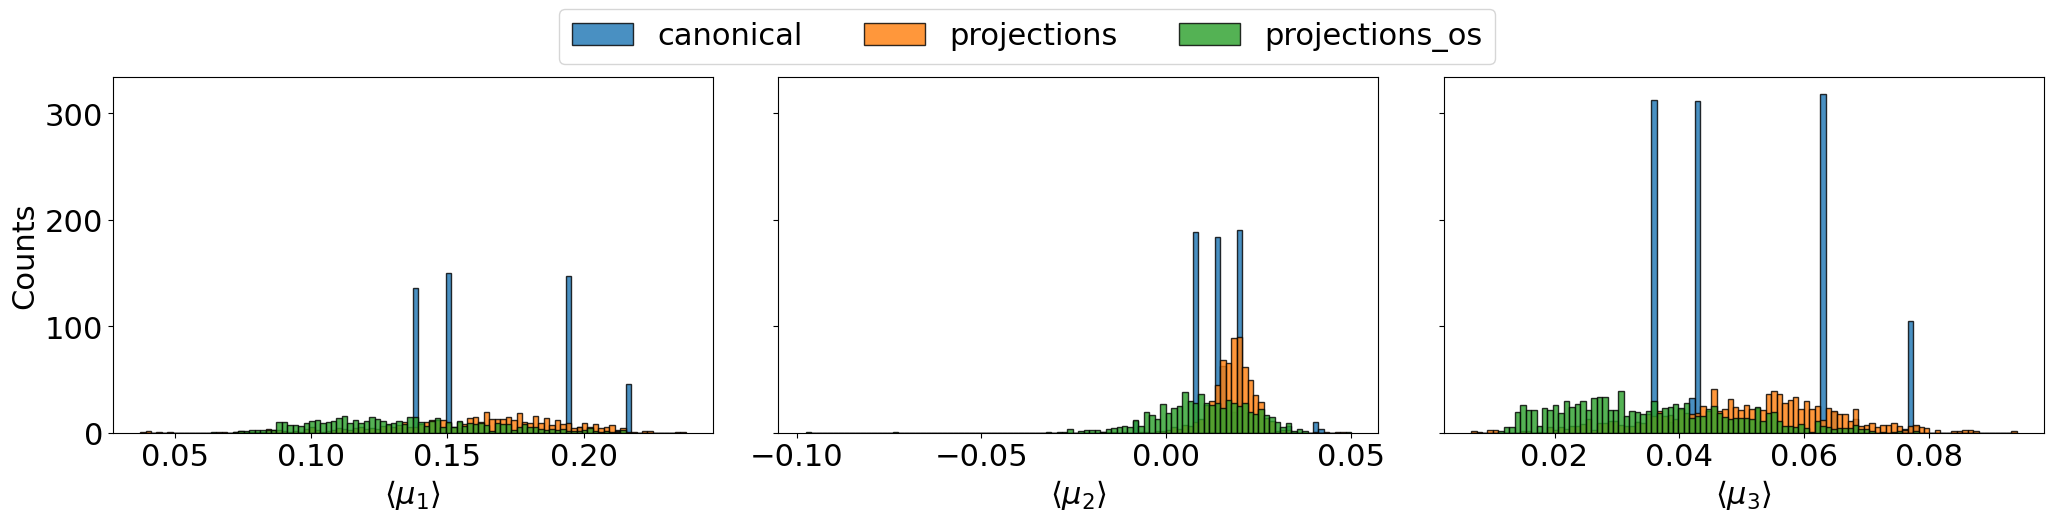

In [103]:
compare_many_orders('normed_moments','\mu')

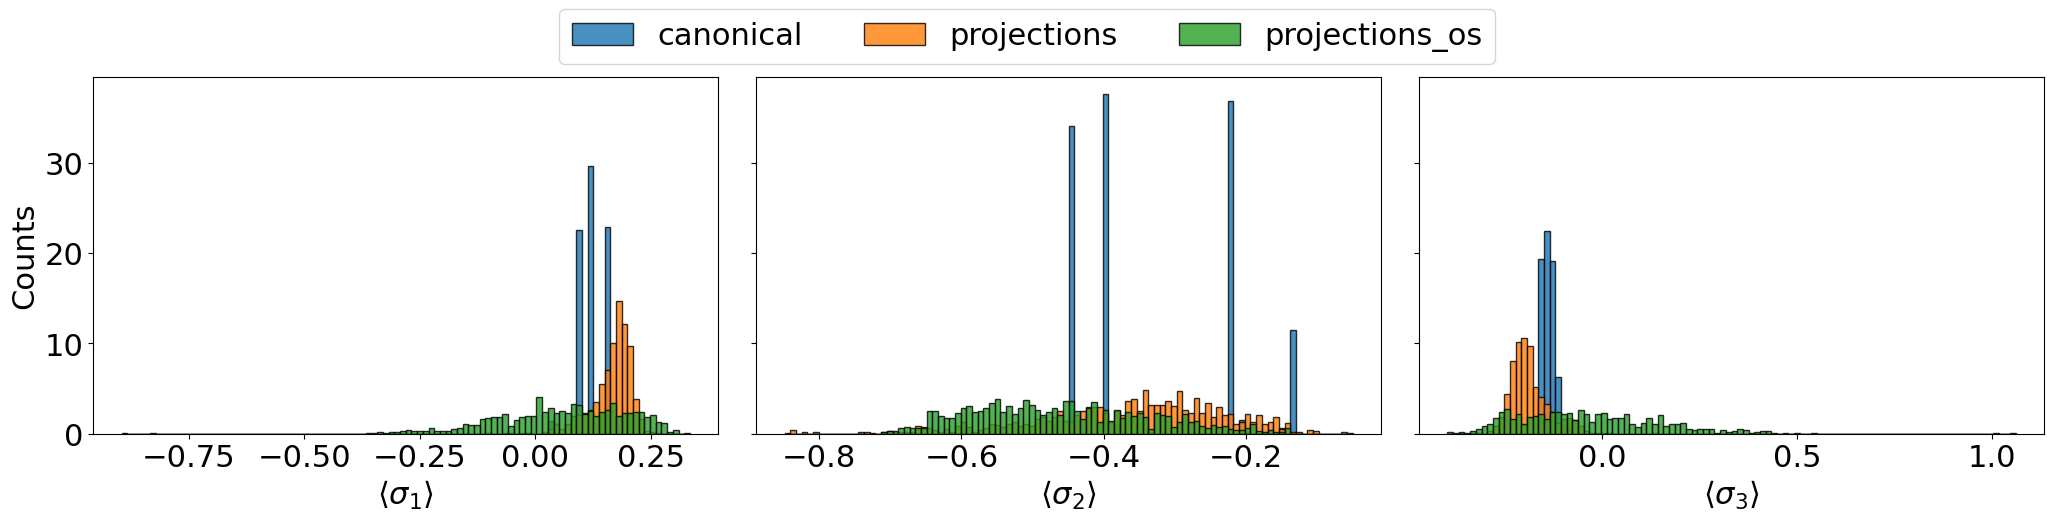

In [104]:
compare_many_orders('sigma', '\sigma')

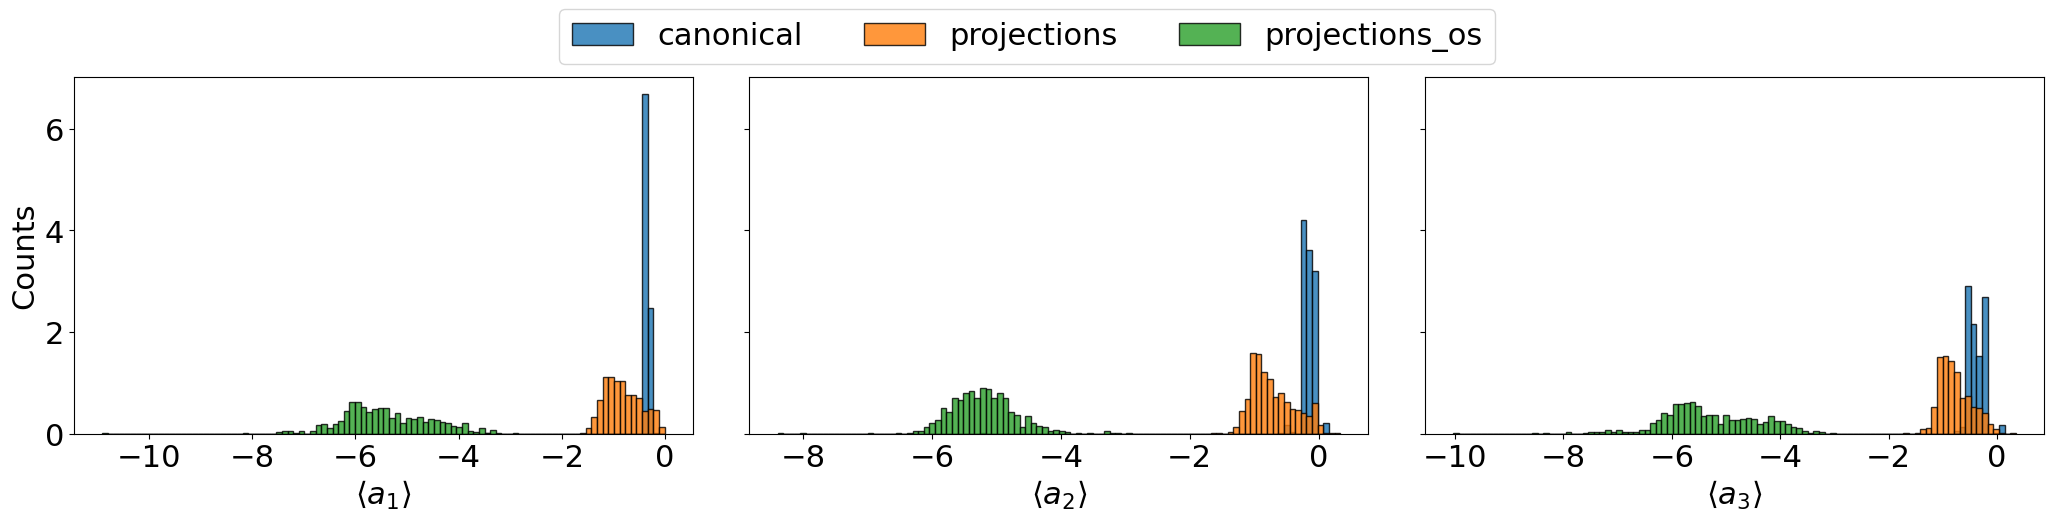

In [105]:
compare_many_orders('an', 'a')

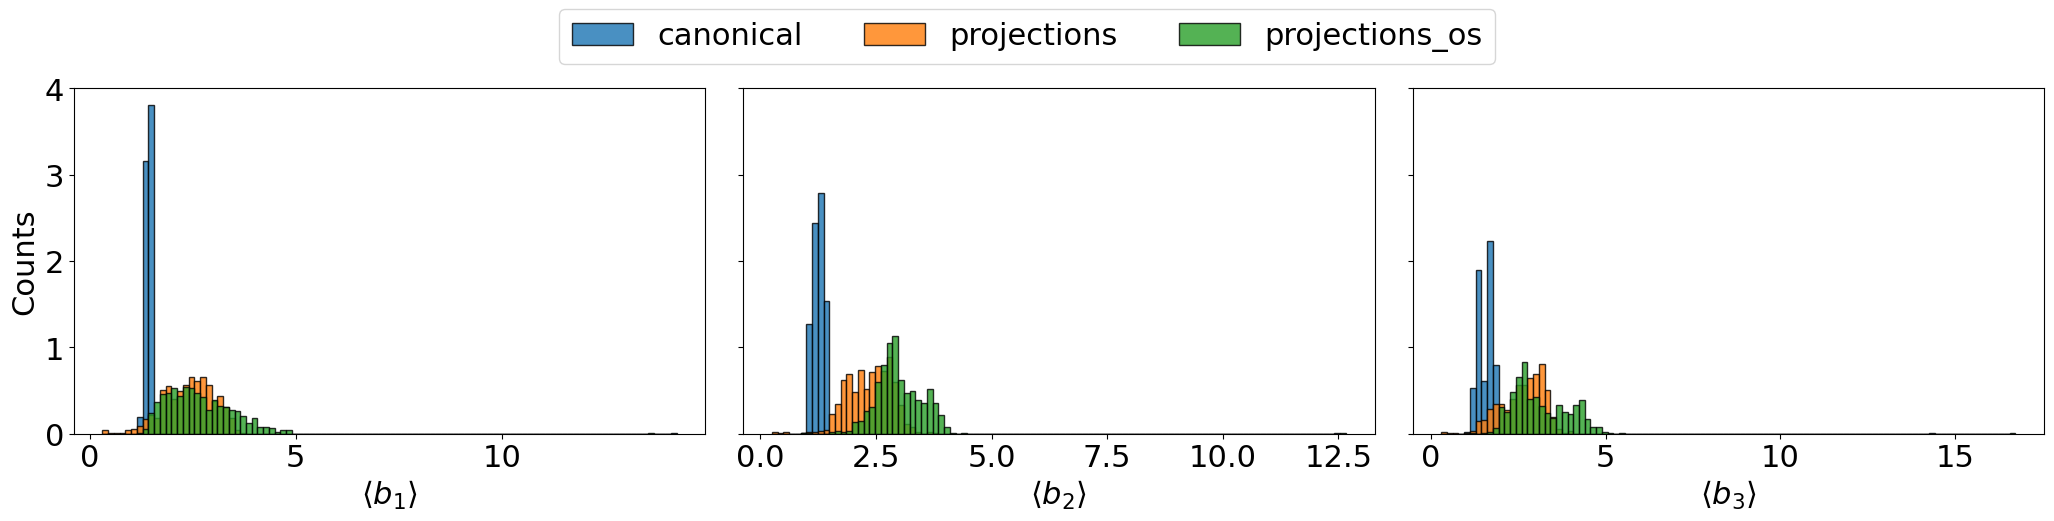

In [106]:
compare_many_orders('bn', 'b')

In [107]:
CP = ['0', 'CN12', 'CN13', 'CN14','CN15','CN16']
CPSYMB=['_{0}',  '{CN_{12}}', '{CN_{13}}', '{CN_{14}}','{CN_{15}}','{CN_{16}}']

In [121]:
featurename = 'normed_moments'
featuresymbol = '\mu'
model = 'canonical'
def compare_cns(featurename, featuresymbol, model):
    fig, ax = plt.subplots(1,3, figsize = (21,5), sharey=True)
    for i, tax in enumerate(ax):
        for case, symbol in zip(CP,CPSYMB):
            featuremain = fr'{featurename}_{i+1}' 
            featurecol = fr'{featuremain}_{case}'
            featuretitle = fr'$\langle {featuresymbol}_{i+1} \rangle$'
            tax.set_xlabel(featuretitle)
            thismin = resultscnav[model].filter(regex=featuremain+'_').min().min()
            thismaxn = resultscnav[model].filter(regex=featuremain+'_').max().max()
        #     = fr'${featuresymbol}_{i} $' for i in range(1,4)}
            tax.hist(resultscnav[model][f'{featurecol}'], label=f'${symbol}$',bins=100, edgecolor='k', alpha=0.7, range=[thismin, thismaxn])
    handles, labels = ax[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.1))
    ax[0].set_ylabel('counts')
    ax[0].set_ylim([0, 500])

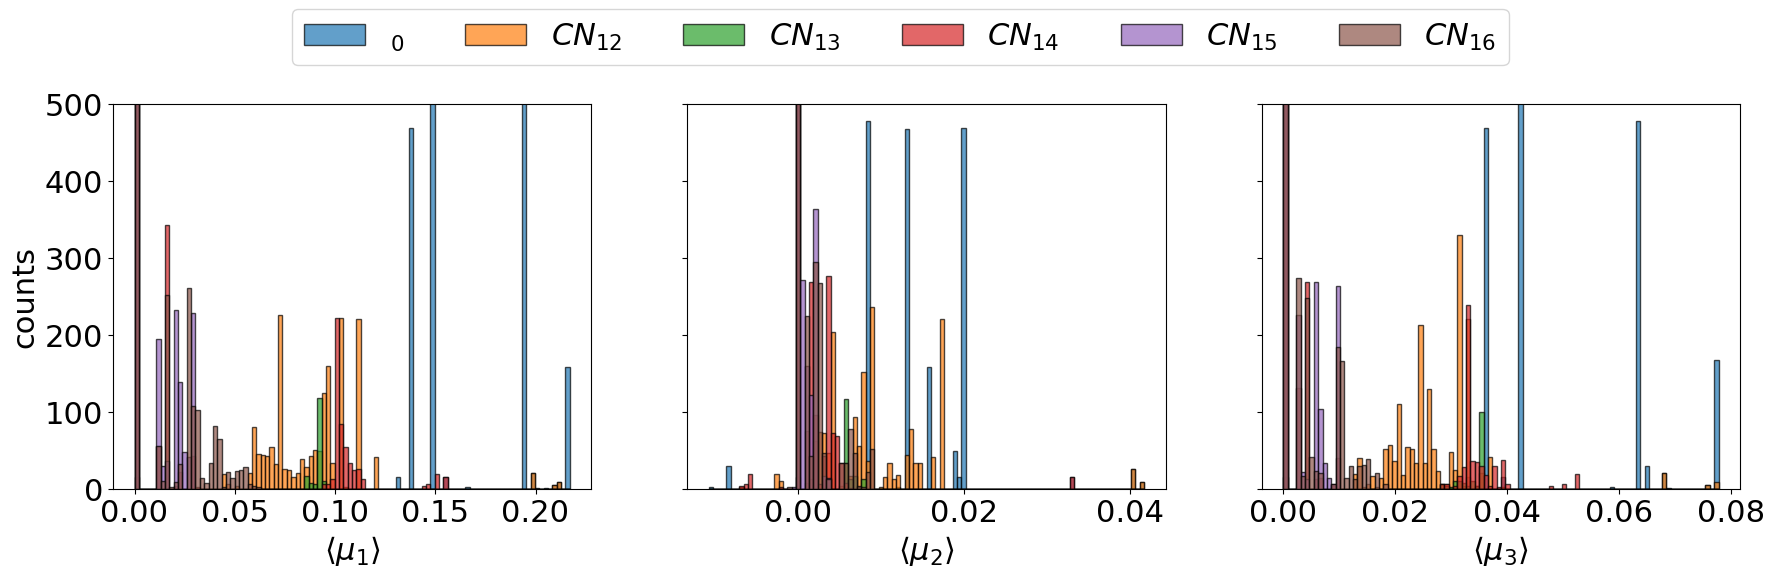

In [122]:
compare_cns('normed_moments', '\mu', 'canonical')

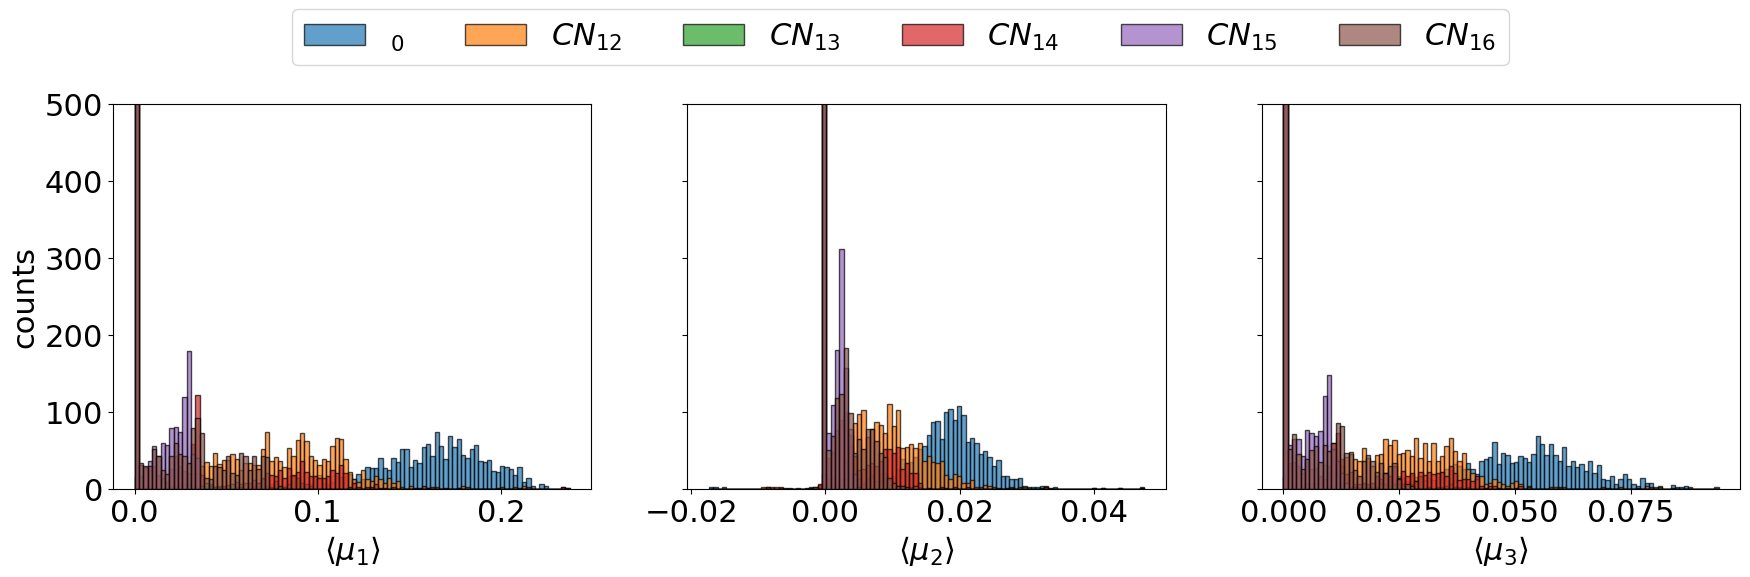

In [123]:
compare_cns('normed_moments', '\mu', 'projections')

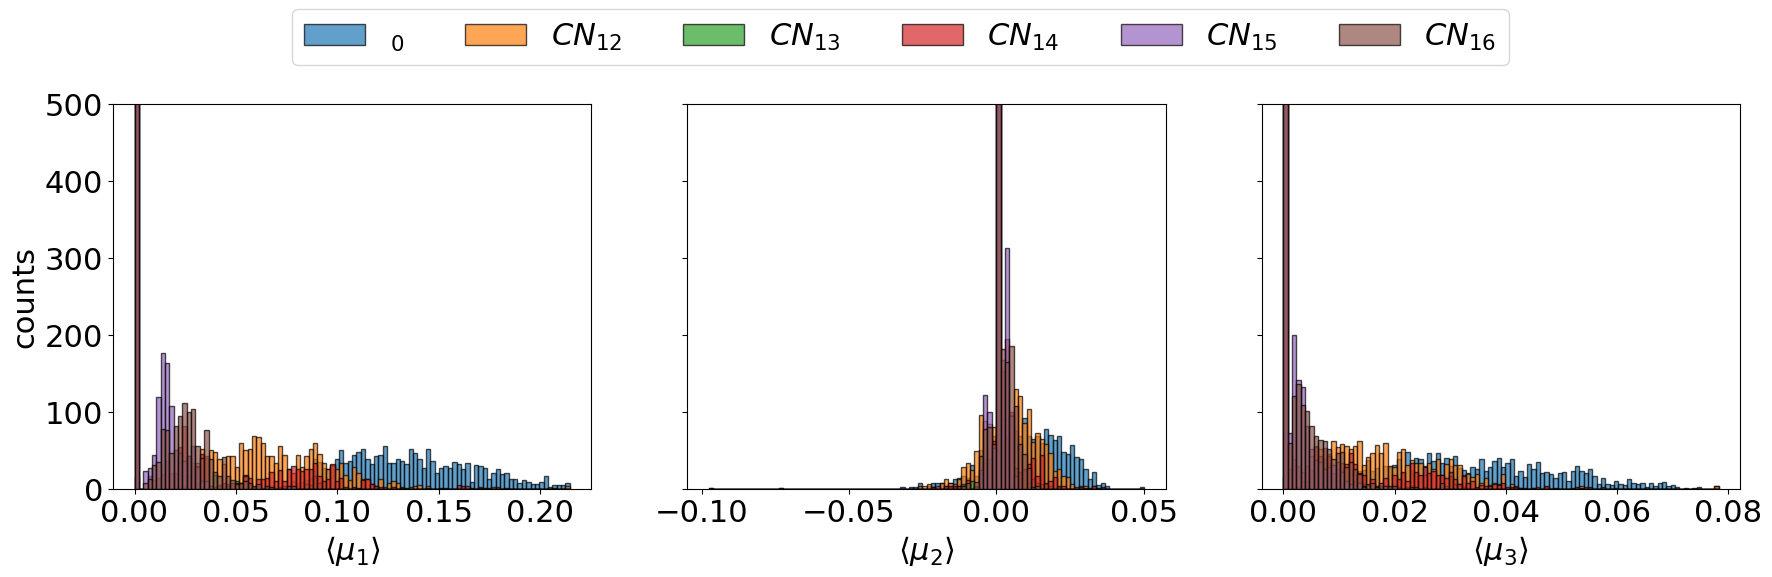

In [124]:
compare_cns('normed_moments', '\mu', 'projections_os')

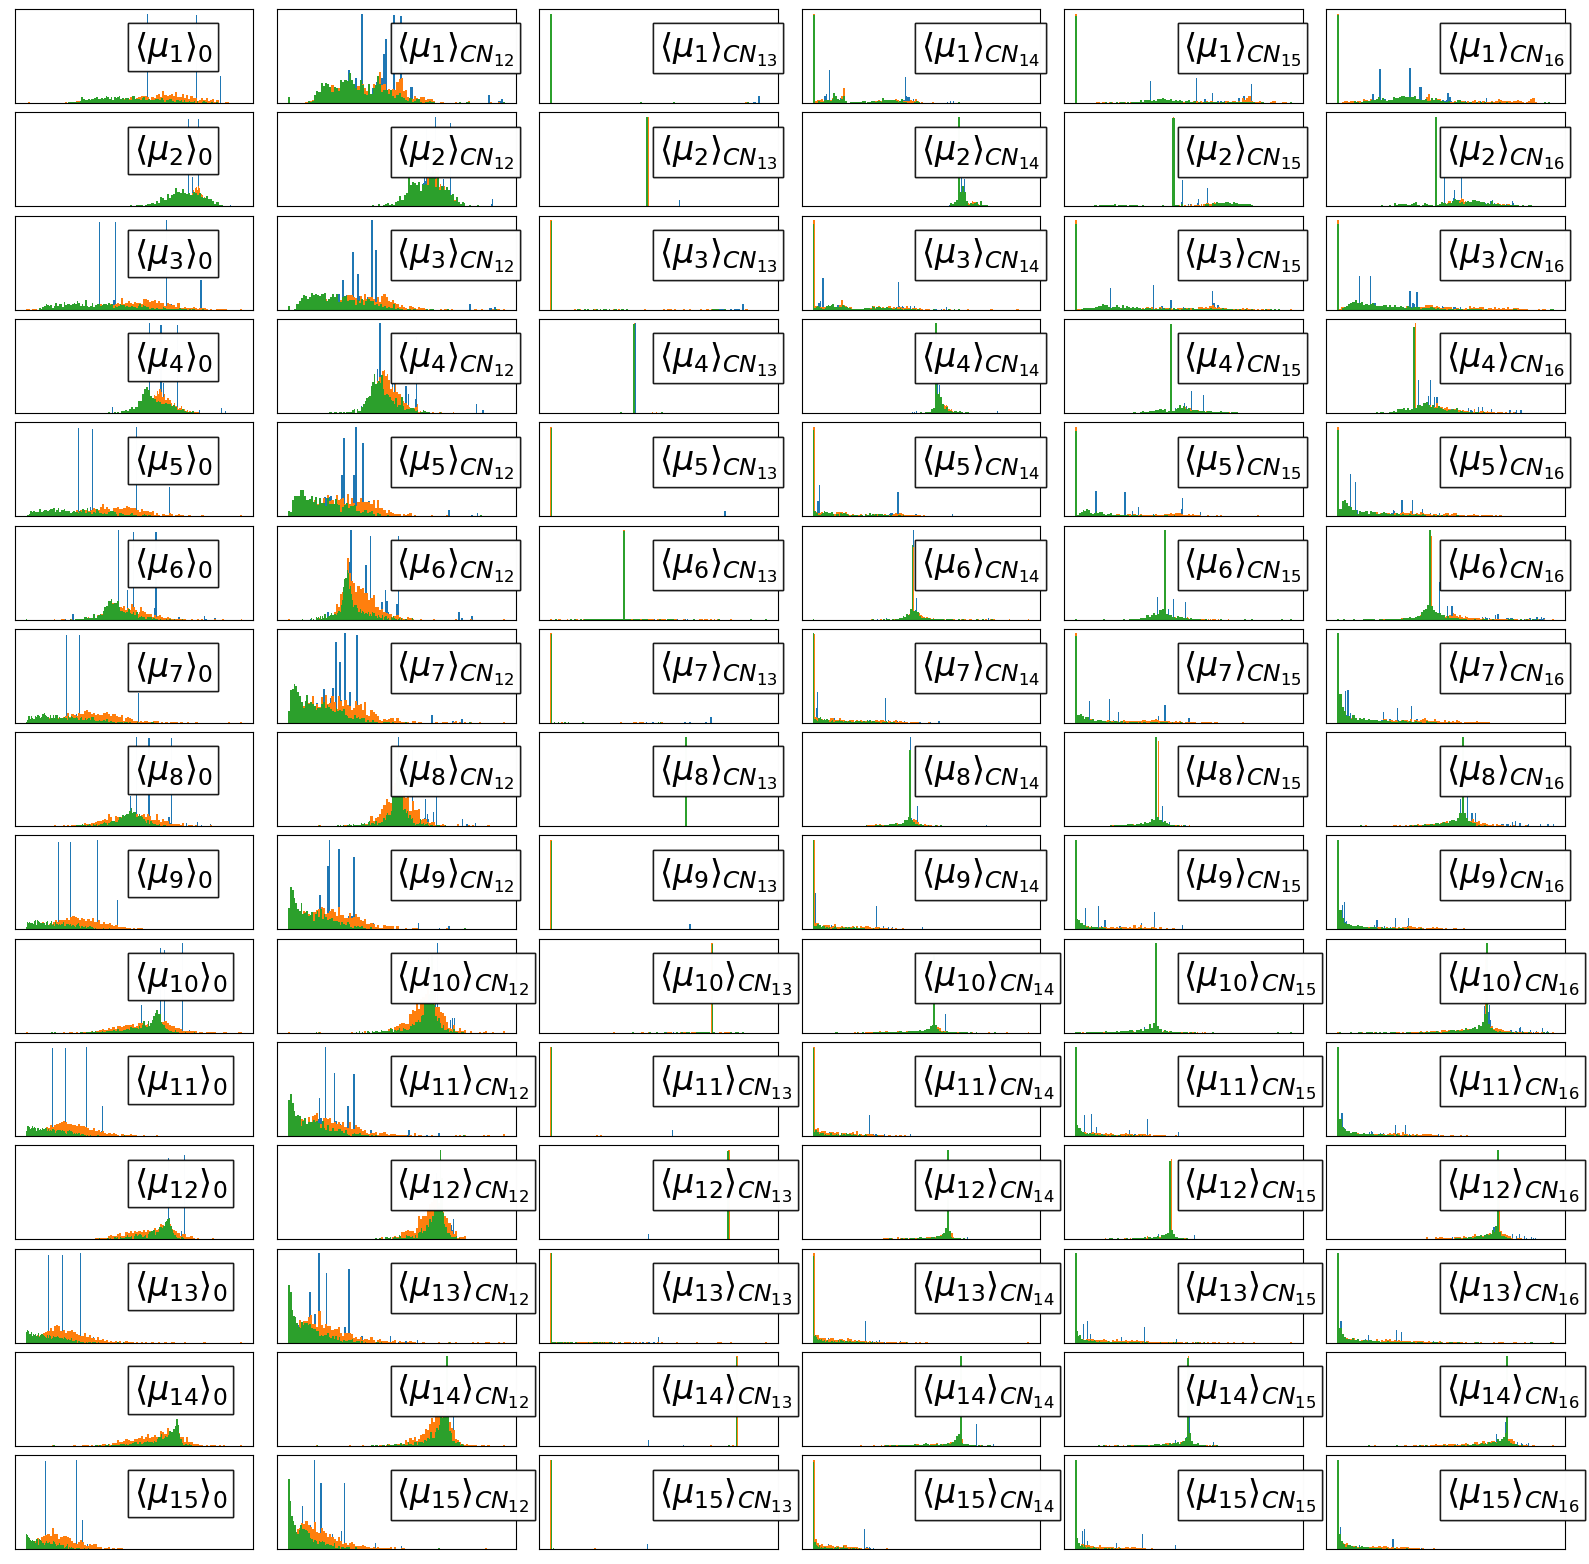

In [109]:
import Tools.DatasetTools.Tools as tl
plotter = tl.Plotting
selection = resultscnav['canonical'].columns.str.contains('normed_moments')
normedmomentnames = resultscnav['canonical'].columns[selection]
normedmomenttitles = pd.Series({name: re.sub('normed_moments_(.*)_',r'$\\langle \\mu_{\1} \\rangle ', name)+'$' for name in normedmomentnames})
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' 0\$','_{0}$', s))
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' CN(.*)\$','_{CN_{\\1}}$', s))
fig, ax = plotter.histoff_realfeatures(resultscnav['canonical'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6)
fig, ax = plotter.histoff_realfeatures(resultscnav['projections'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))
fig, ax = plotter.histoff_realfeatures(resultscnav['projections_os'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))

## Shape factors 

In [126]:
resultscnav['canonical'].filter(regex='sf')

,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Co_pv6W_sv6.C14-BBA.FM,1.106267,1.192875,0.000000,0.000000,0.000000,0.904122
Co_pv6W_sv6.C14-BBA.NM,1.106267,1.192875,0.000000,0.000000,0.000000,0.904122
Cr_pv6W_sv2.D0_19-A3B.FM,1.137590,1.137590,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,1.137590,1.137590,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,1.224174,1.238260,0.000000,1.215240,1.227311,0.000000
...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,1.224170,1.188754,0.000000,1.255536,1.191643,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,1.224170,1.188754,0.000000,1.255536,1.191643,0.000000
Co_pv13W_sv16.chi-ABAB.NM,1.251701,1.437266,1.179081,0.000000,0.000000,1.006199
Co_pv13W_sv16.chi-ABAB.FM,1.251701,1.437266,1.179081,0.000000,0.000000,1.006199


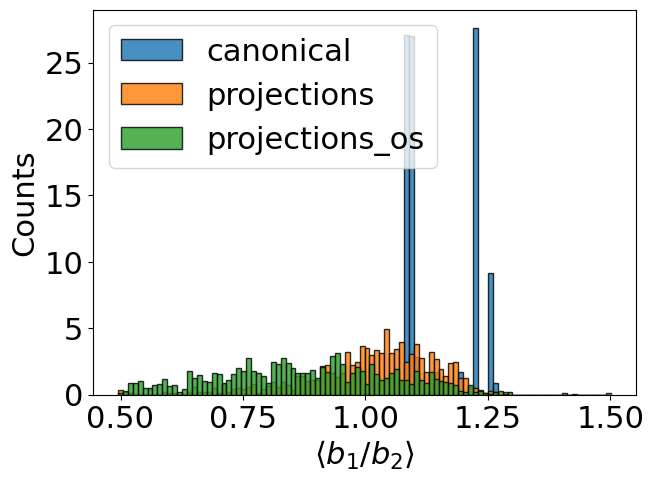

In [129]:
comparefeatures('sf', 'b_1 / b_2', )

# Correlations

In [40]:
BS = pd.read_pickle('Cr-Co-W/FullyCuratedParsedBriefSummary.pkl')

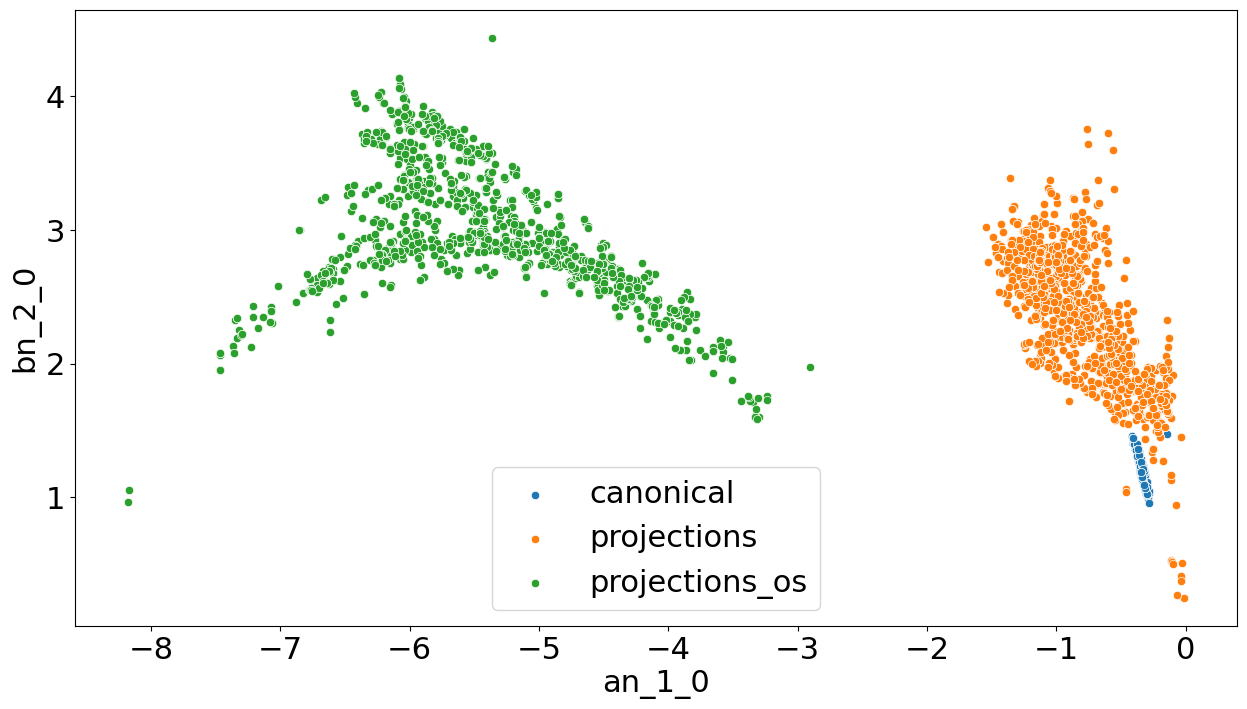

In [142]:
ax = sns.scatterplot(data = resultscnav['canonical'][resultscnav['canonical']['bn_2_0']<4], x = 'an_1_0', y ='bn_2_0')
ax = sns.scatterplot(data = resultscnav['projections'][resultscnav['projections']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax = sns.scatterplot(data = resultscnav['projections_os'][resultscnav['projections_os']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax.legend(['canonical', 'projections', 'projections_os'])

##  shape-factors

In [148]:
BS.index.difference(resultscnav['canonical'].index)

Index([], dtype='object')

In [149]:
resultscnav['canonical'].index.difference(BS.index)

Index([], dtype='object')

In [157]:
models

['canonical', 'projections', 'projections_os']

In [192]:
def target_correlation_scatters (featurename, featuresymbol, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    [sns.scatterplot(x=resultscnav[model][featurename], y = BS['EF'], ax = ax) for model in models]
    ax.set_ylabel('$\Delta E_f$')
    ax.set_xlabel(featuresymbol)
    ax.legend(models)
    return ax

In [218]:
def correlation_vs_order(feature, featuresymbol, order=[1,2,3,4]):
    fig, axes = plt.subplots(1, len(order),  sharey=True, figsize=(7*4, 5))
    for i, ax in enumerate(axes):
        thisfeaturename = f'{feature}_{order[i]}_0'
        thisfeaturesymbol = f'${featuresymbol}_{order[i]}$'
        ax = target_correlation_scatters(thisfeaturename, thisfeaturesymbol, ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(labels), loc='upper center')

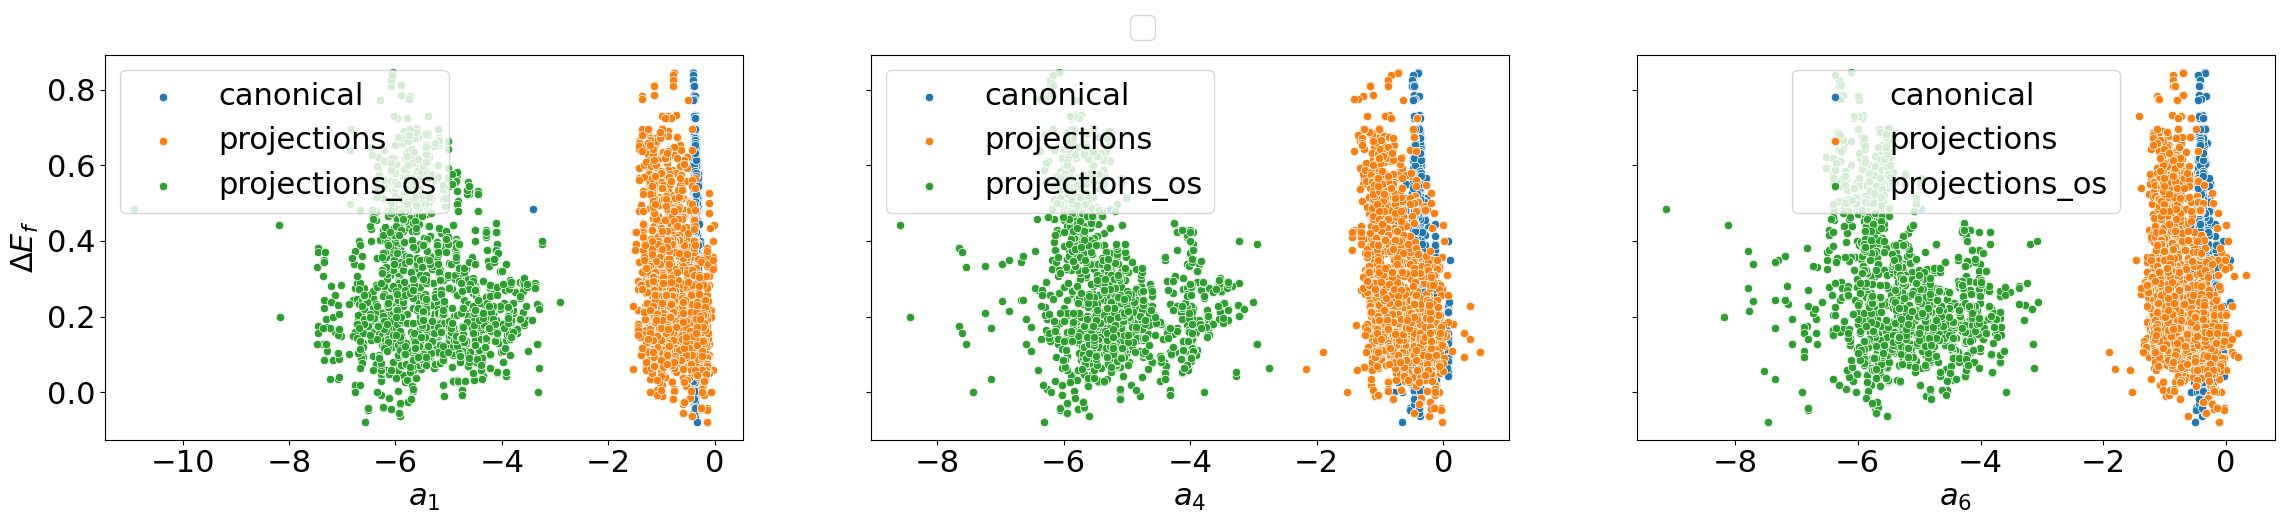

In [219]:
correlation_vs_order('an', 'a', order=[1,4,6])

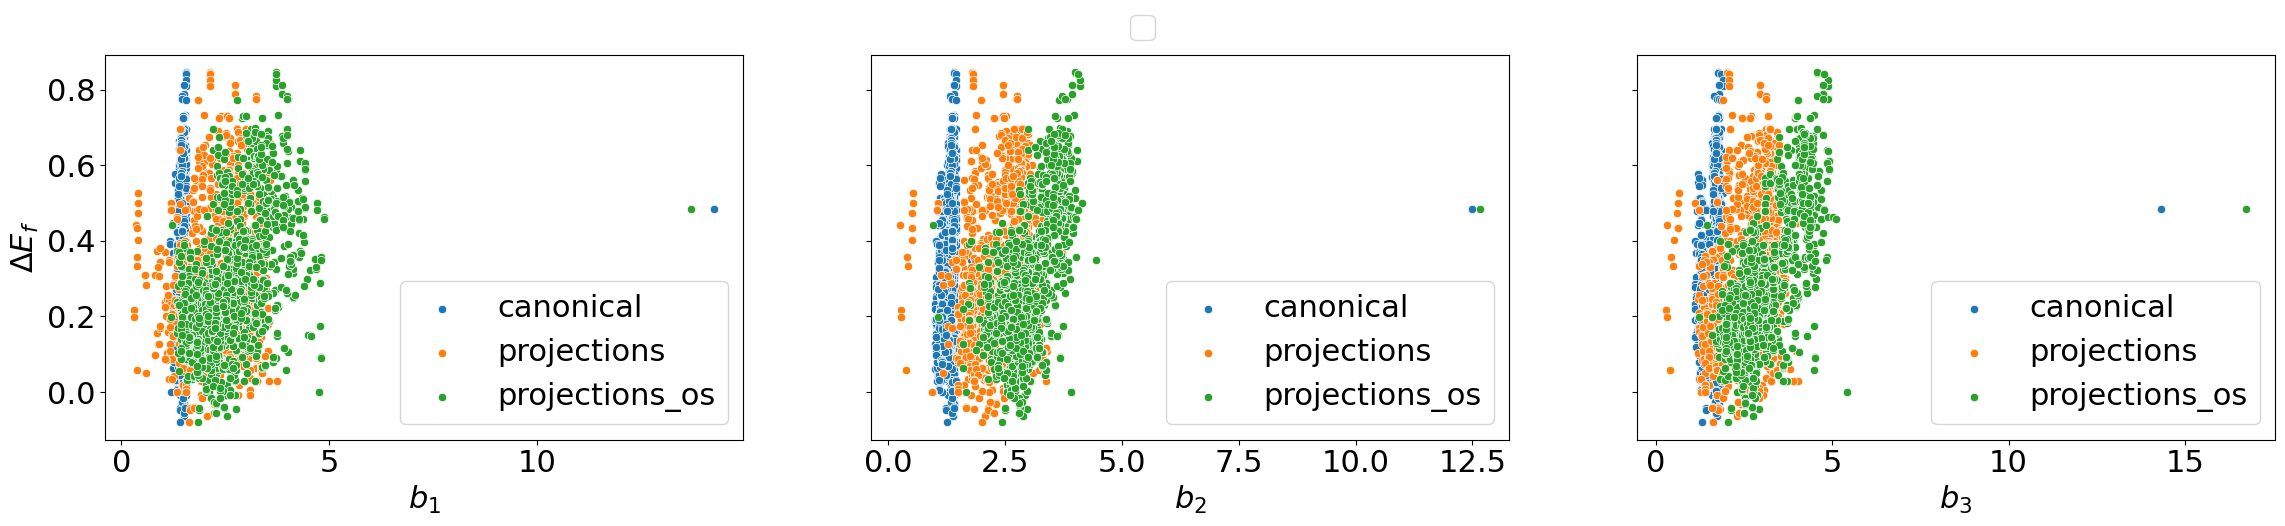

In [223]:
correlation_vs_order('bn', 'b', order=[1,2,3])

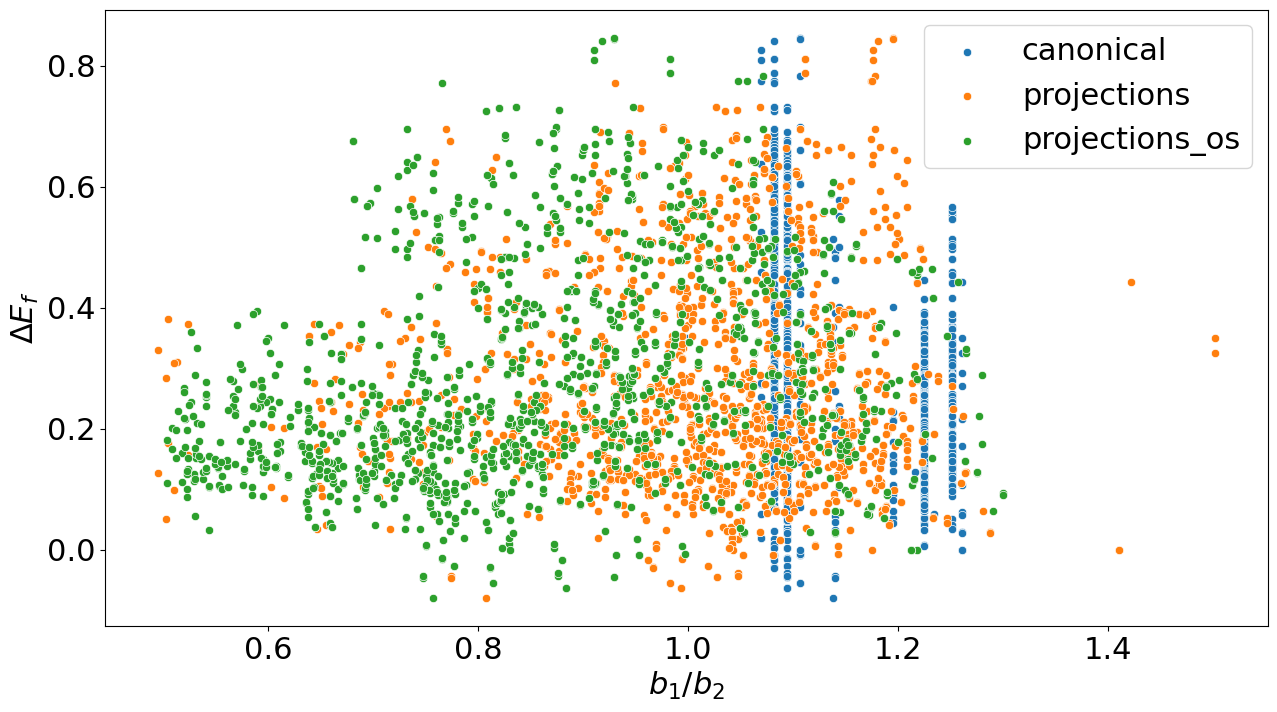

In [228]:
ax = target_correlation_scatters('sf_0', '$b_1 / b_2$')

<AxesSubplot:xlabel='$U_{bind}$', ylabel='$\\Delta E_f$'>

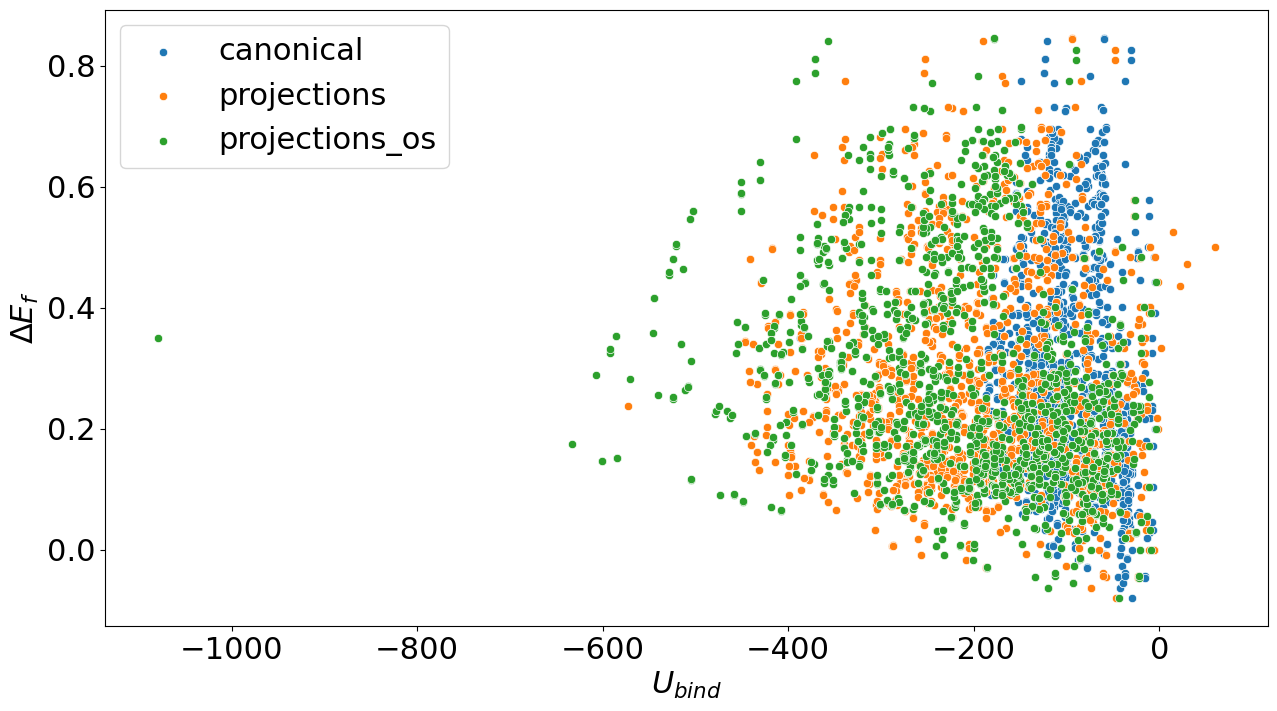

In [231]:
target_correlation_scatters('U_bind', '$U_{bind}$')

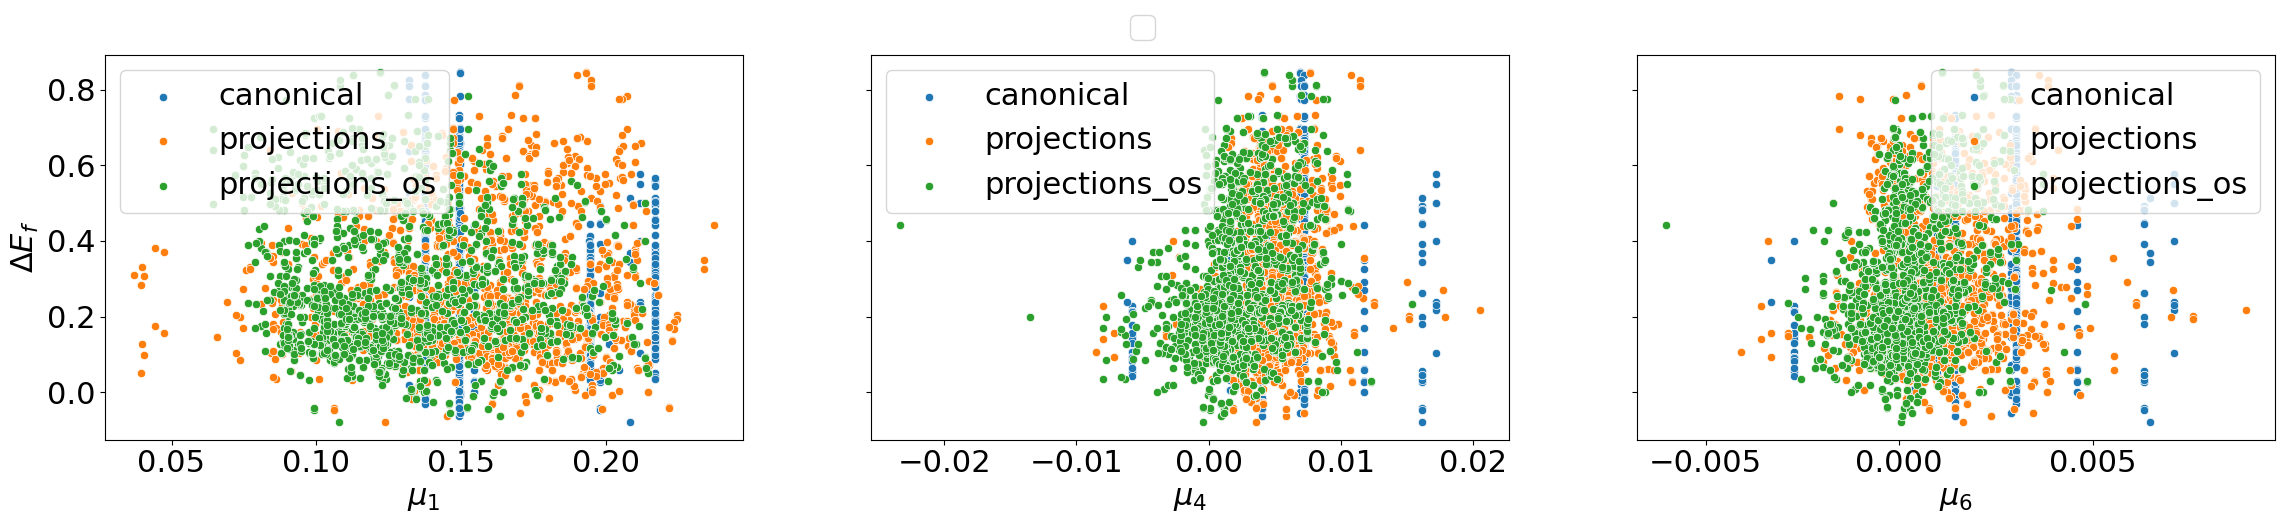

In [220]:
correlation_vs_order('normed_moments', '\mu', order=[1,4,6])

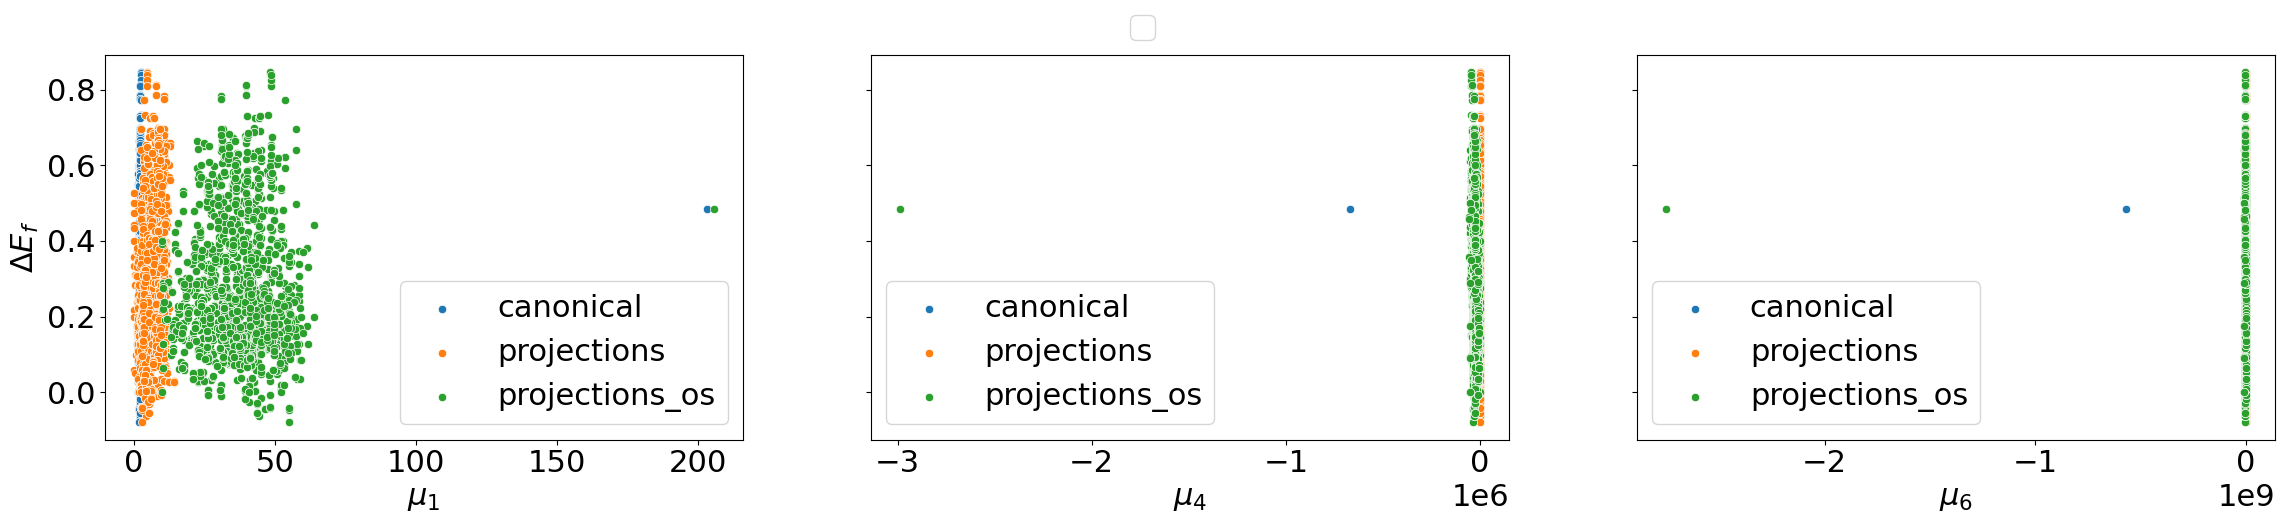

In [221]:
correlation_vs_order('moments', '\mu', order=[1,4,6])

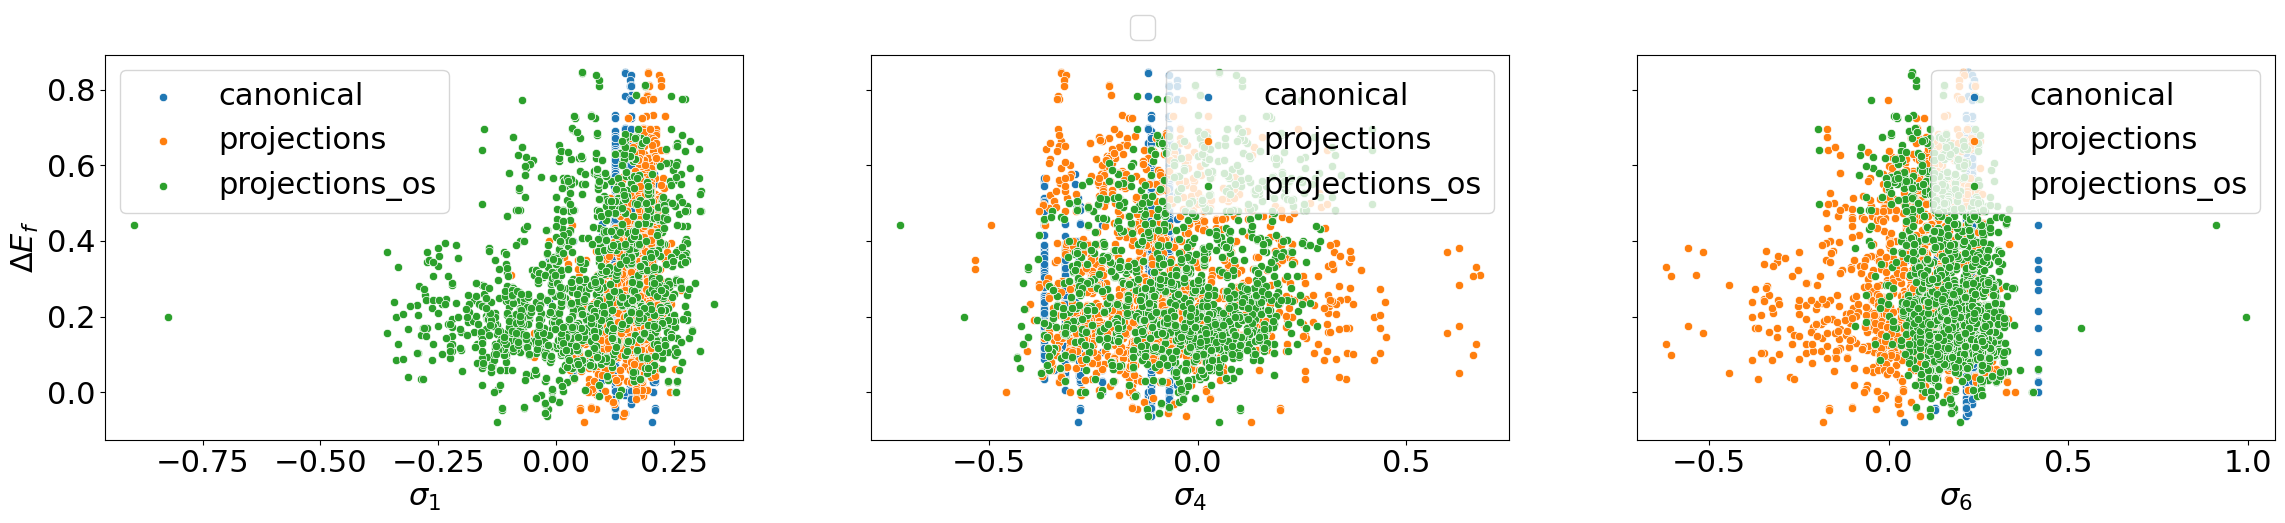

In [222]:
correlation_vs_order('sigma', '\sigma', order=[1,4,6])